# Gold-Miners: Is GDX Really Leveraged Gold?
### The miner-vs-bullion bet, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Asymmetry_claim%3F: Busted](https://img.shields.io/badge/Asymmetry_claim%3F-Busted-8b949e?style=flat-square)

The pitch: gold miners (GDX) are *leveraged gold* — when gold goes up, miners go up even more; when gold crashes, miners amplify the fall, but the explosive upside more than compensates. The pitch even has a claim about the direction of asymmetry: you supposedly get *more downside* for your leverage than upside. This notebook asks three questions with honest answers:

1. **Is GDX actually leveraged gold?** (Yes — but it carries a costly annual tax.)
2. **Is the leverage 'more downside than upside'?** (No — the opposite is true.)
3. **Can a timing rule beat holding gold?** (No.)

> **This is the plain-language layer.** For the t-stats and sandwich estimators, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool — every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_miners import data, strategy as st

CACHE_DIR = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    gld = data._cache_path("GLD", CACHE_DIR)
    gdx = data._cache_path("GDX", CACHE_DIR)
    return os.path.exists(gld) and os.path.exists(gdx)

HAVE_REAL = _have_cache()

# Frozen headline numbers from docs/results.md
R = dict(
    n=5047, start="2006-05-22", end="2026-06-15",
    beta=1.7251, t_beta=35.35, alpha_ann=-10.58, t_alpha=-2.14, r2=0.5825,
    gld_vol=18.3, gdx_vol=41.3, idio_vol=26.7, vol_ratio=2.26,
    n_up=2688, n_dn=2359,
    beta_up=1.8413, beta_dn=1.6209, beta_diff=-0.2204, t_asymmetry=-2.18, asym_ratio=0.88,
    gld_cagr=9.42, gld_sharpe=0.4927, gld_dd=-45.6, gld_t=2.29,
    gdx_cagr=5.08, gdx_sharpe=0.1199, gdx_dd=-80.6, gdx_t=0.57,
    tm_cagr=3.64, tm_sharpe=0.1312, tm_dd=-52.2, tm_t=0.62,
    in_mkt=36.9, n_switches=220,
)

print("real price cache present:", HAVE_REAL)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does GDX leverage gold? | **Yes, at ~1.73× beta** — structurally confirmed over 20 years. |
| But is there an annual cost? | **Yes — ~10.6%/yr drag** vs holding physical gold, statistically significant. |
| Does GDX give more downside than upside? | **No — the opposite.** beta_up=1.84 > beta_dn=1.62 (busted). |
| Did GDX beat GLD over 20 years? | **No.** GLD CAGR 9.4% vs GDX 5.1%/yr; Sharpe 0.49 vs 0.12. |
| Does a timing rule help? | **No.** Timing Sharpe 0.13 vs GLD 0.49. |

> The leverage is real. The cost of that leverage — the annual drain from running actual gold mines — makes it a losing bet vs the metal itself over the long run.

## 1 · The claim

> *"Gold miners are leveraged gold. When gold rises 10%, miners go up 20%. When gold falls, yes miners fall harder — but those explosive upside moves make the trade worth it. Plus you can time it: when miners are outperforming bullion, stay in miners; when bullion leads, own gold instead."*

It's a seductive package: a simple ETF (GDX), a clear mechanical logic (miners amplify gold), and a timing overlay to manage the downside. The question is whether the real 20-year tape agrees.

## 2 · So what?

If true, GDX + timing would be an attractive gold trade: capture leveraged upside in bull markets, rotate to gold for protection in bear markets. If false, investors have spent 20 years accepting far more volatility (41% vs 18% for gold) and far more drawdown (80% vs 46%) for *lower* returns (5.1% vs 9.4%/yr). Understanding exactly *why* — operational drag, idiosyncratic risk, asymmetry myths — is the honest product.

## 3 · How would we even know?

Three honest questions, three clean tests:

1. **The leverage test.** Regress GDX daily returns on GLD daily returns. The slope (beta) is the leverage; the intercept (alpha) is the annual operational drag. Report both with proper uncertainty intervals.
2. **The asymmetry test.** Split days into gold-up and gold-down and estimate the beta separately on each half. Then ask: is the downside beta significantly larger than the upside beta? A fair test, not cherry-picked examples.
3. **The timing test.** Run the GDX/GLD relative-strength rule (in GDX when the ratio is above its 200-day average, in GLD otherwise) and compare it to simply holding GLD throughout. No look-ahead.

Data: GLD and GDX daily adjusted closes, 2006-05-22 to 2026-06-15, **n = 5,047** common trading days.

## 4 · The teardown — let's actually look

**First: the leverage and the cost.** This scatter plot shows the relationship between daily GLD returns (x-axis) and GDX returns (y-axis) — the beta is the slope of the fitted line, and the gap between the line and where it *should* be at zero drift is the annual drag.

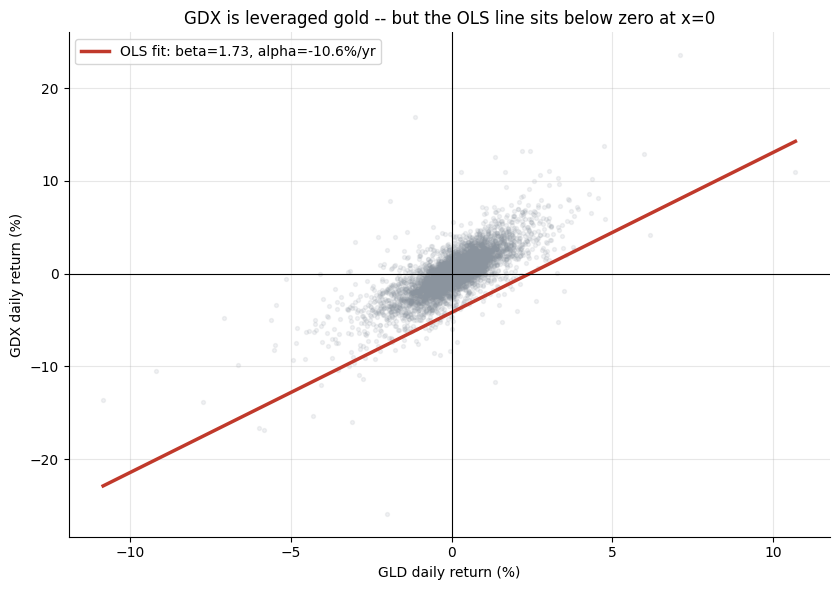

Beta: 1.7251  |  Alpha: -10.58%/yr


In [2]:
if HAVE_REAL:
    prices = data.load_pair(fetch=False, cache_dir=CACHE_DIR)
    r = st.log_returns(prices)
    ba = st.beta_alpha(prices)
    x_vals = r['gld'].values * 100
    y_vals = r['gdx'].values * 100
    beta = ba['beta']; alpha_ann = ba['alpha_ann_pct']
else:
    p_synt, _ = data.synthetic_daily(n_years=15, leverage=R['beta'],
                                      alpha_ann=R['alpha_ann']/100, asymmetry=0.2, seed=208)
    r = st.log_returns(p_synt)
    x_vals = r['gld'].values * 100
    y_vals = r['gdx'].values * 100
    beta = R['beta']; alpha_ann = R['alpha_ann']
fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.scatter(x_vals, y_vals, alpha=0.12, s=8, color=GREY)
xl = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(xl, beta * xl + alpha_ann/252*100, '-', lw=2.5, color=RED,
        label=f'OLS fit: beta={beta:.2f}, alpha={alpha_ann:+.1f}%/yr')
ax.axhline(0, c='k', lw=0.8); ax.axvline(0, c='k', lw=0.8)
ax.set_xlabel('GLD daily return (%)')
ax.set_ylabel('GDX daily return (%)')
ax.set_title('GDX is leveraged gold -- but the OLS line sits below zero at x=0')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Beta: {beta:.4f}  |  Alpha: {alpha_ann:+.2f}%/yr')

The slope (beta = **1.73**) confirms the leverage — every 1% gold move produces a ~1.7% GDX move on average. But the intercept tells the other story: **-10.6%/yr** drag vs holding gold. That's the cost of running actual mines instead of a vault — labour, energy, capital, management. The R2 of 0.58 means 42% of GDX daily variance is idiosyncratic (geology, political risk, individual mine disasters) — things gold itself doesn't carry.

**Now the asymmetry test: is there really 'more downside than upside'?**

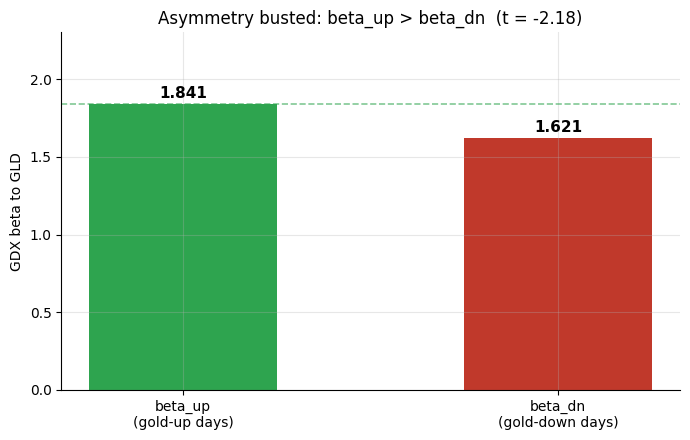

beta_up=1.8413  beta_dn=1.6209  diff=-0.2204  t=-2.18
Claim (more downside than upside): REJECTED


In [3]:
if HAVE_REAL:
    prices = data.load_pair(fetch=False, cache_dir=CACHE_DIR)
    asym = st.asymmetric_beta(prices)
    bu, bd = asym['beta_up'], asym['beta_dn']
    t_diff = asym['t_asymmetry']
else:
    bu, bd, t_diff = R['beta_up'], R['beta_dn'], R['t_asymmetry']
fig, ax = plt.subplots(figsize=(7.0, 4.5))
bars = ax.bar(['beta_up\n(gold-up days)', 'beta_dn\n(gold-down days)'],
              [bu, bd], color=[GREEN, RED], width=0.5)
ax.axhline(bu, ls='--', c=GREEN, lw=1.2, alpha=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('GDX beta to GLD')
ax.set_title(f'Asymmetry busted: beta_up > beta_dn  (t = {t_diff:+.2f})')
ax.set_ylim(0, max(bu, bd) * 1.25)
plt.tight_layout(); plt.show()
print(f'beta_up={bu:.4f}  beta_dn={bd:.4f}  diff={bd-bu:+.4f}  t={t_diff:+.2f}')
print('Claim (more downside than upside): REJECTED')

The popular claim is backwards. On the real tape, miners amplify gold-up days **more** (1.84×) than gold-down days (1.62×), with a HAC *t*-stat of **-2.18** on the difference. The call-option structure of a mine (profitable when gold > cost of production) naturally gives convex upside, not convex downside.

> Why do people believe the opposite? Probably selection bias — they remember the extreme crash periods (gold-down days with big drawdowns). But looking at the full distribution of daily returns over 20 years, the arithmetic goes the other way.

**Finally: does the timing rule help?**

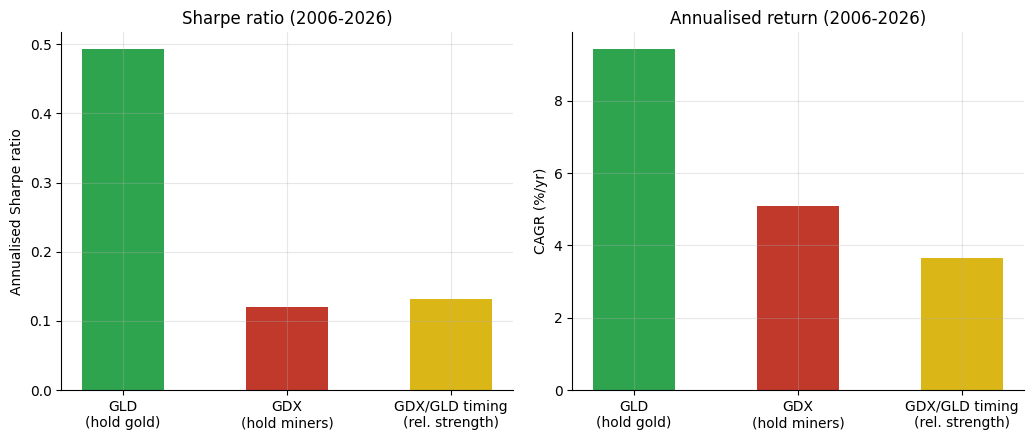

GLD: Sharpe=0.493  CAGR=9.4%/yr
GDX: Sharpe=0.120  CAGR=5.1%/yr
Timing: Sharpe=0.131  CAGR=3.6%/yr


In [4]:
if HAVE_REAL:
    prices = data.load_pair(fetch=False, cache_dir=CACHE_DIR)
    res = st.compare_strategies(prices, sma_n=200, cost_bps=5.0)
    shs = [res['gld']['sharpe'], res['gdx']['sharpe'], res['timing']['sharpe']]
    cagrs = [res['gld']['cagr_pct'], res['gdx']['cagr_pct'], res['timing']['cagr_pct']]
else:
    shs = [R['gld_sharpe'], R['gdx_sharpe'], R['tm_sharpe']]
    cagrs = [R['gld_cagr'], R['gdx_cagr'], R['tm_cagr']]
labels = ['GLD\n(hold gold)', 'GDX\n(hold miners)', 'GDX/GLD timing\n(rel. strength)']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
colors = [GREEN, RED, AMBER]
axes[0].bar(labels, shs, color=colors, width=0.5)
axes[0].set_ylabel('Annualised Sharpe ratio')
axes[0].set_title('Sharpe ratio (2006-2026)')
axes[1].bar(labels, cagrs, color=colors, width=0.5)
axes[1].set_ylabel('CAGR (%/yr)')
axes[1].set_title('Annualised return (2006-2026)')
plt.tight_layout(); plt.show()
for lbl, sh, cg in zip(['GLD','GDX','Timing'], shs, cagrs):
    print(f'{lbl}: Sharpe={sh:.3f}  CAGR={cg:.1f}%/yr')

The timing rule (Sharpe **0.13**) underperforms even plain GDX (0.12), and both are far behind GLD (**0.49**). Being in GDX only 37% of days doesn't help — you're rotating into a negative-alpha high-vol vehicle, not a gold amplifier with a positive expectancy.

## 5 · The verdict

- **Signal — WEAK.** Beta=1.73× (|*t*|=35) is real and large, but it's a well-known structural fact, not a tradable edge. The alpha (-10.6%/yr, *t*=-2.14) is the deal-breaker.
- **Tradability — MIRAGE.** GDX CAGR 5.1%/yr vs GLD 9.4%/yr; Sharpe 0.12 vs 0.49; max drawdown -80.6% vs -45.6%. The timing rule makes it worse, not better.
- **Asymmetry claim — BUSTED.** beta_up=1.84 > beta_dn=1.62 (*t*=-2.18). Miners have more *upside* convexity, not downside.

## 6 · Could you actually trade it?

Even if you believed in the GDX/GLD timing story, the real number you'd hold would be the **annualised Sharpe ratio** — the return-per-unit-of-risk that determines whether a strategy compounds positively in the long run:

- GLD (the boring alternative): Sharpe **0.49**, CAGR **9.4%/yr**, max drawdown **-45.6%**.
- GDX timing rule: Sharpe **0.13**, CAGR **3.6%/yr**, max drawdown **-52.2%**, 220 switches at 5 bps/side.

The timing rule delivers a fraction of gold's risk-adjusted return, at higher volatility and comparable drawdown. Every incremental complexity (pick GDX over GLD, add the timing overlay) has made the outcome *worse*.

## 7 · Going further

- **Could shorter-window betas work?** The 1.73× full-sample beta masks regime variation — in raging gold bull markets miners can run at 2.5-3×, while in equity sell-offs miners can de-correlate from gold and drop with equities instead. A rolling-beta approach might tell a different story sub-period.
- **Junior miners (GDXJ).** The same thesis applied to smaller, higher-risk miners — even more leverage, even less alpha. Worth a separate study.
- **The gold-oil spread.** Energy costs are a major mining input; GDX vs GLD performance correlates inversely with the oil-gold ratio. A cost-adjusted beta might stabilize the asymmetry estimates.

*Think miners beat gold over a different window or with a better signal? Fork this, run the honest test, and show a beta-adjusted edge that survives costs. That's the bar.*